# Lab 8 Demo

# Lab 8: Introduction to the tidyverse

This lab introduces tidyverse workflows for describing one variable at a
time, then using `filter()` and `group_by()` for focused summaries.

------------------------------------------------------------------------

## Learning outcomes

By the end of this lab, you should be able to:

1.  Load a tidyverse dataset and inspect its variables.
2.  Identify whether a variable is numerical or categorical.
3.  Check category levels for categorical variables.
4.  Recode a variable type when numeric values are actually category
    codes.
5.  For one numerical variable, compute mean and SD and make a
    histogram.
6.  For one categorical variable, compute count and proportion.
7.  Use `filter()` to subset data with conditions.
8.  Use `group_by()` with `summarise()` to compare groups.

------------------------------------------------------------------------

## Summary of new functions

| Function                      | What it does                            |
|-------------------------------|-----------------------------------------|
| `library(tidyverse)`          | Loads the core tidyverse packages       |
| `glimpse(df)`                 | Quick view of variable names and types  |
| `class(x)`                    | Reports object type                     |
| `levels(x)`                   | Shows categories if `x` is a factor     |
| `mutate()`                    | Adds/changes variables                  |
| `factor()`                    | Converts a variable to categorical type |
| `summarise()`                 | Computes summary statistics             |
| `n()`                         | Counts rows inside `summarise()`        |
| `filter()`                    | Keeps rows that satisfy conditions      |
| `group_by()`                  | Creates groups before summaries         |
| `ggplot() + geom_histogram()` | Makes a histogram for numerical data    |
| `count()`                     | Quick count by category                 |

------------------------------------------------------------------------

## Setup

In [ ]:


library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We’ll use the built-in `mpg` dataset from **ggplot2** (loaded with
tidyverse). Each row is a car model with variables like city MPG
(`cty`), highway MPG (`hwy`), drive type (`drv`), and class (`class`).

In [ ]:
data("mpg", package = "ggplot2")
glimpse(mpg)

Rows: 234
Columns: 11
$ manufacturer <chr> "audi", "audi", "audi", "audi", "audi", "audi", "audi", "…
$ model        <chr> "a4", "a4", "a4", "a4", "a4", "a4", "a4", "a4 quattro", "…
$ displ        <dbl> 1.8, 1.8, 2.0, 2.0, 2.8, 2.8, 3.1, 1.8, 1.8, 2.0, 2.0, 2.…
$ year         <int> 1999, 1999, 2008, 2008, 1999, 1999, 2008, 1999, 1999, 200…
$ cyl          <int> 4, 4, 4, 4, 6, 6, 6, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 8, 8, …
$ trans        <chr> "auto(l5)", "manual(m5)", "manual(m6)", "auto(av)", "auto…
$ drv          <chr> "f", "f", "f", "f", "f", "f", "f", "4", "4", "4", "4", "4…
$ cty          <int> 18, 21, 20, 21, 16, 18, 18, 18, 16, 20, 19, 15, 17, 17, 1…
$ hwy          <int> 29, 29, 31, 30, 26, 26, 27, 26, 25, 28, 27, 25, 25, 25, 2…
$ fl           <chr> "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p…
$ class        <chr> "compact", "compact", "compact", "compact", "compact", "c…


In [ ]:
glimpse(mpg)

Rows: 234
Columns: 15
$ manufacturer            <chr> "audi", "audi", "audi", "audi", "audi", "audi"…
$ model                   <chr> "a4", "a4", "a4", "a4", "a4", "a4", "a4", "a4 …
$ displ                   <dbl> 1.8, 1.8, 2.0, 2.0, 2.8, 2.8, 3.1, 1.8, 1.8, 2…
$ year                    <int> 1999, 1999, 2008, 2008, 1999, 1999, 2008, 1999…
$ cyl                     <int> 4, 4, 4, 4, 6, 6, 6, 4, 4, 4, 4, 6, 6, 6, 6, 6…
$ trans                   <chr> "auto(l5)", "manual(m5)", "manual(m6)", "auto(…
$ drv                     <chr> "f", "f", "f", "f", "f", "f", "f", "4", "4", "…
$ cty                     <int> 18, 21, 20, 21, 16, 18, 18, 18, 16, 20, 19, 15…
$ hwy                     <int> 29, 29, 31, 30, 26, 26, 27, 26, 25, 28, 27, 25…
$ fl                      <chr> "p", "p", "p", "p", "p", "p", "p", "p", "p", "…
$ class                   <chr> "compact", "compact", "compact", "compact", "c…
$ trans_code              <fct> auto(l5), manual(m5), manual(m6), auto(av), au…
$ drv_numeric_code

------------------------------------------------------------------------

## Part 1: One numerical variable

Let’s describe `hwy` (highway MPG), a numerical variable.

### 1A) Check type

In [ ]:
mpg$hwy

[1] 29 29 31 30 26 26 27 26 25 28 27 25 25 25 25 24 25 23 20 15 20 17 17 26 23
 [26] 26 25 24 19 14 15 17 27 30 26 29 26 24 24 22 22 24 24 17 22 21 23 23 19 18
 [51] 17 17 19 19 12 17 15 17 17 12 17 16 18 15 16 12 17 17 16 12 15 16 17 15 17
 [76] 17 18 17 19 17 19 19 17 17 17 16 16 17 15 17 26 25 26 24 21 22 23 22 20 33
[101] 32 32 29 32 34 36 36 29 26 27 30 31 26 26 28 26 29 28 27 24 24 24 22 19 20
[126] 17 12 19 18 14 15 18 18 15 17 16 18 17 19 19 17 29 27 31 32 27 26 26 25 25
[151] 17 17 20 18 26 26 27 28 25 25 24 27 25 26 23 26 26 26 26 25 27 25 27 20 20
[176] 19 17 20 17 29 27 31 31 26 26 28 27 29 31 31 26 26 27 30 33 35 37 35 15 18
[201] 20 20 22 17 19 18 20 29 26 29 29 24 44 29 26 29 29 29 29 23 24 44 41 29 26
[226] 28 29 29 29 28 29 26 26 26

In [ ]:
class(mpg$hwy)

[1] "integer"

In [ ]:
mean(mpg$hwy)

[1] 23.44017

In [ ]:
mpg %>%
  summarize(
     meanHWY=mean(hwy),
     meanCity=mean(cty),
     medianCity=median(cty),
     numberCars = n()
)

meanHWY,meanCity,medianCity,numberCars
<dbl>,<dbl>,<dbl>,<int>
23.44017,16.85897,17,234


In [ ]:
mpg %>%
  summarise(
    MeanHwy = mean(hwy),
    MeanCity = mean(cty),
    medianHwy = median(hwy)
  )

MeanHwy,MeanCity,medianHwy
<dbl>,<dbl>,<dbl>
23.44017,16.85897,24


In [ ]:
mpg %>%
  summarise(
     meanHwy = mean(hwy),
     median = median(hwy),
     sd = sd(hwy),
     meanCity = mean(cty)
  )

meanHwy,median,sd,meanCity
<dbl>,<dbl>,<dbl>,<dbl>
23.44017,24,5.954643,16.85897


### 1B) Compute mean and SD

In [ ]:
mpg %>%
  summarise(
    mean_hwy = mean(hwy),
    sd_hwy = sd(hwy)
  )

mean_hwy,sd_hwy
<dbl>,<dbl>
23.44017,5.954643


### 1C) Make a histogram

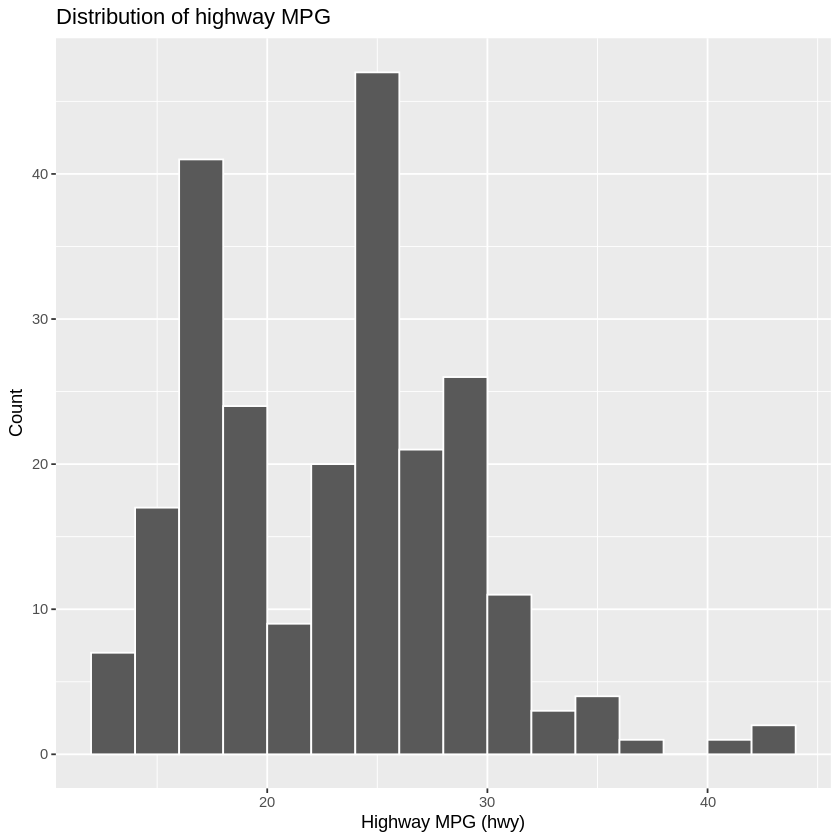

In [ ]:
ggplot(mpg, aes(x = hwy)) +
  geom_histogram(binwidth = 2, boundary = 0, color = "white") +
  labs(
    title = "Distribution of highway MPG",
    x = "Highway MPG (hwy)",
    y = "Count"
  )

------------------------------------------------------------------------

## Part 2: One categorical variable

Now describe `drv` (drive type), a categorical variable.

### 2A) Check type and categories

In [ ]:
class(mpg$drv)
levels(mpg$drv)

[1] "character"

NULL

In [ ]:
mpg$drv

[1] "f" "f" "f" "f" "f" "f" "f" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4"
 [19] "r" "r" "r" "r" "r" "r" "r" "r" "r" "r" "4" "4" "4" "4" "f" "f" "f" "f"
 [37] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "4" "4" "4" "4" "4" "4"
 [55] "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4"
 [73] "4" "4" "r" "r" "r" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4"
 [91] "r" "r" "r" "r" "r" "r" "r" "r" "r" "f" "f" "f" "f" "f" "f" "f" "f" "f"
[109] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "4" "4" "4" "4"
[127] "4" "4" "4" "4" "4" "4" "4" "4" "r" "r" "r" "4" "4" "4" "4" "f" "f" "f"
[145] "f" "f" "f" "f" "f" "f" "4" "4" "4" "4" "f" "f" "f" "f" "f" "4" "4" "4"
[163] "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "f"
[181] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f"
[199] "4" "4" "4" "4" "4" "4" "4" "4" "4" "f" "f" "f" "f" "f" "f" "f" "f" "f"
[217] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f"

In [ ]:
class(mpg$trans)

[1] "character"

In [ ]:
mpg$trans_code = factor(mpg$trans)
class(mpg$trans_code)
levels(mpg$trans_code)

[1] "factor"

[1] "auto(av)"   "auto(l3)"   "auto(l4)"   "auto(l5)"   "auto(l6)"  
 [6] "auto(s4)"   "auto(s5)"   "auto(s6)"   "manual(m5)" "manual(m6)"

In [ ]:
mpg$drv

[1] "f" "f" "f" "f" "f" "f" "f" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4"
 [19] "r" "r" "r" "r" "r" "r" "r" "r" "r" "r" "4" "4" "4" "4" "f" "f" "f" "f"
 [37] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "4" "4" "4" "4" "4" "4"
 [55] "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4"
 [73] "4" "4" "r" "r" "r" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4"
 [91] "r" "r" "r" "r" "r" "r" "r" "r" "r" "f" "f" "f" "f" "f" "f" "f" "f" "f"
[109] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "4" "4" "4" "4"
[127] "4" "4" "4" "4" "4" "4" "4" "4" "r" "r" "r" "4" "4" "4" "4" "f" "f" "f"
[145] "f" "f" "f" "f" "f" "f" "4" "4" "4" "4" "f" "f" "f" "f" "f" "4" "4" "4"
[163] "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "4" "f"
[181] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f"
[199] "4" "4" "4" "4" "4" "4" "4" "4" "4" "f" "f" "f" "f" "f" "f" "f" "f" "f"
[217] "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f" "f"

### 2B) Compute counts and proportions

In [ ]:
table(mpg$drv)


  4   f   r 
103 106  25 

In [ ]:
mpg %>%
  count(drv, name = "count") %>%
  mutate(proportion = count / sum(count))

drv,count,proportion
<chr>,<int>,<dbl>
4,103,0.4401709
f,106,0.4529915
r,25,0.1068376


------------------------------------------------------------------------

## Part 3: Change variable type (numeric codes -\> categories)

In `mpg`, `cyl` (number of cylinders) is numeric, but in many analyses
we treat it as categories (4, 5, 6, 8) rather than a continuous scale.

In [ ]:
class(mpg$cyl)

[1] "integer"

Convert `cyl` to a factor:

In [ ]:
mpg2 <- mpg %>%
  mutate(cyl = factor(cyl))

class(mpg2$cyl)
levels(mpg2$cyl)

[1] "factor"

[1] "4" "5" "6" "8"

Now compute count and proportion for `cyl` categories:

In [ ]:
mpg2 %>%
  count(cyl, name = "count") %>%
  mutate(proportion = count / sum(count))

cyl,count,proportion
<fct>,<int>,<dbl>
4,81,0.34615385
5,4,0.01709402
6,79,0.33760684
8,70,0.29914530


------------------------------------------------------------------------

## Part 4: `filter()` with conditions

Use `filter()` to keep only rows meeting conditions.

Examples:

In [ ]:
mpg |>
  select(model, hwy) |>
  head(10)

model,hwy
<chr>,<int>
a4,29
a4,29
a4,31
a4,30
a4,26
a4,26
a4,27
a4 quattro,26
a4 quattro,25


In [ ]:
mpg %>%
  group_by(model) %>%
  filter(model == "a4" | model == "corolla") %>%
  filter(hwy >30 & cyl >3) %>%
  summarize(
      mean(hwy),
      sd(hwy),
      n()
  )

model,mean(hwy),sd(hwy),n()
<chr>,<dbl>,<dbl>,<int>
a4,31,NA,1
corolla,35,1.632993,4


In [ ]:
levels(factor(mpg$model))

[1] "4runner 4wd"            "a4"                     "a4 quattro"            
 [4] "a6 quattro"             "altima"                 "c1500 suburban 2wd"    
 [7] "camry"                  "camry solara"           "caravan 2wd"           
[10] "civic"                  "corolla"                "corvette"              
[13] "dakota pickup 4wd"      "durango 4wd"            "expedition 2wd"        
[16] "explorer 4wd"           "f150 pickup 4wd"        "forester awd"          
[19] "grand cherokee 4wd"     "grand prix"             "gti"                   
[22] "impreza awd"            "jetta"                  "k1500 tahoe 4wd"       
[25] "land cruiser wagon 4wd" "malibu"                 "maxima"                
[28] "mountaineer 4wd"        "mustang"                "navigator 2wd"         
[31] "new beetle"             "passat"                 "pathfinder 4wd"        
[34] "ram 1500 pickup 4wd"    "range rover"            "sonata"                
[37] "tiburon"                "toyota tacoma 4wd"

In [ ]:
# remember that "or" is a vertical line |
mpg %>%
  filter(hwy >=20) %>%
  filter(model =="a4" | model == "corolla") %>%
  select(year, trans, hwy) %>%
  head(2)

year,trans,hwy
<int>,<chr>,<int>
1999,auto(l5),29
1999,manual(m5),29


In [ ]:
glimpse(mpg)

Rows: 234
Columns: 12
$ manufacturer <chr> "audi", "audi", "audi", "audi", "audi", "audi", "audi", "…
$ model        <chr> "a4", "a4", "a4", "a4", "a4", "a4", "a4", "a4 quattro", "…
$ displ        <dbl> 1.8, 1.8, 2.0, 2.0, 2.8, 2.8, 3.1, 1.8, 1.8, 2.0, 2.0, 2.…
$ year         <int> 1999, 1999, 2008, 2008, 1999, 1999, 2008, 1999, 1999, 200…
$ cyl          <int> 4, 4, 4, 4, 6, 6, 6, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 8, 8, …
$ trans        <chr> "auto(l5)", "manual(m5)", "manual(m6)", "auto(av)", "auto…
$ drv          <chr> "f", "f", "f", "f", "f", "f", "f", "4", "4", "4", "4", "4…
$ cty          <int> 18, 21, 20, 21, 16, 18, 18, 18, 16, 20, 19, 15, 17, 17, 1…
$ hwy          <int> 29, 29, 31, 30, 26, 26, 27, 26, 25, 28, 27, 25, 25, 25, 2…
$ fl           <chr> "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p…
$ class        <chr> "compact", "compact", "compact", "compact", "compact", "c…
$ trans_code   <fct> auto(l5), manual(m5), manual(m6), auto(av), auto(l5), man…


In [ ]:
# Cars with highway MPG at least 30
mpg %>%
  filter(hwy >= 30) %>%
  select(manufacturer, model, hwy) %>%
  head()

manufacturer,model,hwy
<chr>,<chr>,<int>
audi,a4,31
audi,a4,30
chevrolet,malibu,30
honda,civic,33
honda,civic,32
honda,civic,32


In [ ]:
# SUVs only
mpg %>%
  filter(class == "suv") %>%
  select(manufacturer, model, class, hwy) %>%
  head()

manufacturer,model,class,hwy
<chr>,<chr>,<chr>,<int>
chevrolet,c1500 suburban 2wd,suv,20
chevrolet,c1500 suburban 2wd,suv,15
chevrolet,c1500 suburban 2wd,suv,20
chevrolet,c1500 suburban 2wd,suv,17
chevrolet,c1500 suburban 2wd,suv,17
chevrolet,k1500 tahoe 4wd,suv,19


In [ ]:
# SUVs with 4-wheel drive
mpg %>%
  filter(class == "suv", drv == "4") %>%
  select(manufacturer, model, class, drv, hwy) %>%
  head()

manufacturer,model,class,drv,hwy
<chr>,<chr>,<chr>,<chr>,<int>
chevrolet,k1500 tahoe 4wd,suv,4,19
chevrolet,k1500 tahoe 4wd,suv,4,14
chevrolet,k1500 tahoe 4wd,suv,4,15
chevrolet,k1500 tahoe 4wd,suv,4,17
dodge,durango 4wd,suv,4,17
dodge,durango 4wd,suv,4,17


------------------------------------------------------------------------

## Part 5: `group_by()` + `summarise()`

Now summarize a numerical variable by groups.

### 5A) Mean and SD of highway MPG by drive type

In [ ]:
mpg %>%
  group_by(drv) %>%
  summarise(
    n = n(),
    mean_hwy = mean(hwy),
    sd_hwy = sd(hwy)
  )

drv,n,mean_hwy,sd_hwy
<chr>,<int>,<dbl>,<dbl>
4,103,19.17476,4.078704
f,106,28.16038,4.206881
r,25,21.00000,3.662877


### 5B) Mean and SD of highway MPG by vehicle class

In [ ]:
mpg %>%
  group_by(class) %>%
  summarise(
    n = n(),
    mean_hwy = mean(hwy),
    sd_hwy = sd(hwy)
  ) %>%
  arrange(desc(mean_hwy))

class,n,mean_hwy,sd_hwy
<chr>,<int>,<dbl>,<dbl>
compact,47,28.29787,3.781620
subcompact,35,28.14286,5.375012
midsize,41,27.29268,2.135930
2seater,5,24.80000,1.303840
minivan,11,22.36364,2.062655
suv,62,18.12903,2.977973
pickup,33,16.87879,2.274280


# Conversion between numeric and factors

We can use `as.numeric` to convert a variable to be numerical and `as.factor` or just `factor` to convert to a categorical variable.  The other types of objects we've seen in R (logical, character) can also be converted to via the `as.`, e.g. `as.character`.

In [ ]:
class(mpg$drv)

[1] "character"

In [ ]:
mpg$drv_code = factor(mpg$drv)
class(mpg$drv_code)

[1] "factor"

In [ ]:
levels(mpg$drv_code)

[1] "4" "f" "r"

In [ ]:
mpg$drv_numeric_code = as.numeric(mpg$drv_code)

In [ ]:
mpg$drv_numeric_code

[1] 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 3 1 1 1 1 2 2 2 2 2
 [38] 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [75] 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2
[112] 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 1 1 1 1 2 2 2 2 2 2 2
[149] 2 2 1 1 1 1 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2
[186] 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[223] 2 2 2 2 2 2 2 2 2 2 2 2

In [ ]:
mpg$drv_numeric_code_factor = factor(mpg$drv_numeric_code)
levels(mpg$drv_numeric_code_factor)

[1] "1" "2" "3"

------------------------------------------------------------------------

